In [15]:
from sklearn import datasets
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터를 train, test로 나누는 데 사용됨
from sklearn.preprocessing import StandardScaler # 데이터를 표준화하는 데 사용됨
from sklearn.tree import DecisionTreeClassifier # 결정 트리 모델을 학습시키는 데 사용됨
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트
from sklearn.svm import SVC # 서포트 벡터 머신
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델
from sklearn.metrics import accuracy_score # 모델의 예측 성능 평가
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
from sklearn.preprocessing import StandardScaler # 데이터를 표준화하는 데 사용됨
data = datasets.load_wine()
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [7]:
print(data.columns)

AttributeError: columns

In [6]:
print(data.isnull().sum())

AttributeError: isnull

In [16]:
x = data['data']
y = data['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [17]:
# 데이터 정규화
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) # train 데이터의 평균과 표준편차를 계산하고 변환
x_test = scaler.transform(x_test) # test 데이터를 변환 -> train 데이터에서 구한 평균과 표준편차를 그대로 사용

In [18]:
# 결정 트리 학습 및 평가
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train) # 학습
dt_pred = dt_model.predict(x_test) # 예측
dt_accuracy = accuracy_score(y_test, dt_pred) # 정답률
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.9333


In [19]:

# 랜덤 포레스트 학습 및 평가
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 1.0000


In [20]:

# SVM 학습 및 평가
svm_model = SVC()
svm_model.fit(x_train, y_train)
svm_pred = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 1.0000


In [21]:

# 로지스틱 회귀 학습 및 평가
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 1.0000


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(x_train, y_train)
ly_preds = model.predict(x_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 0.09816152326529204
평균제곱근오차 0.09816152326529204
평균제곱근오차 0.09816152326529204


<>:16: SyntaxWarning: invalid decimal literal
<>:16: SyntaxWarning: invalid decimal literal
/tmp/ipykernel_12807/1334833135.py:16: SyntaxWarning: invalid decimal literal
  sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


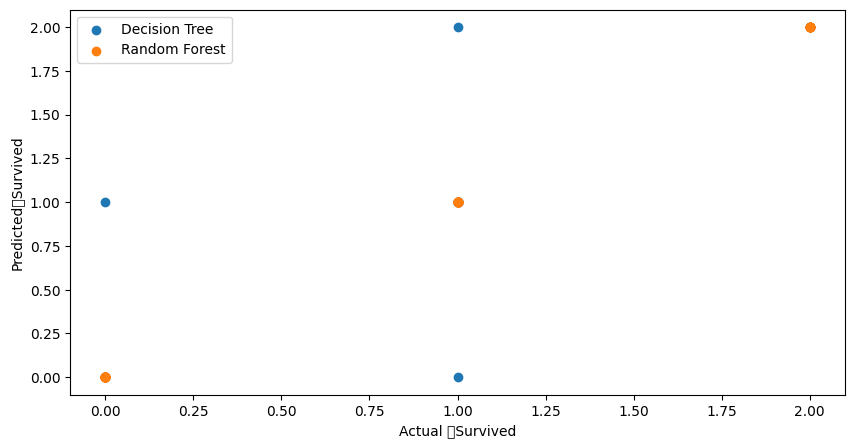

In [26]:


import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(y_test, dt_pred, label='Decision Tree')
plt.scatter(y_test, rf_pred, label='Random Forest')

plt.xlabel("Actual 	Survived")
plt.ylabel("Predicted	Survived")
plt.legend()

plt.show()

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.3628 - loss: 1.2315 - val_accuracy: 0.5517 - val_loss: 0.9922
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4513 - loss: 1.0243 - val_accuracy: 0.7931 - val_loss: 0.8569
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5575 - loss: 0.8697 - val_accuracy: 0.9310 - val_loss: 0.7539
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7788 - loss: 0.7574 - val_accuracy: 1.0000 - val_loss: 0.6712
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8938 - loss: 0.6204 - val_accuracy: 1.0000 - val_loss: 0.5932
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9204 - loss: 0.5425 - val_accuracy: 0.9655 - val_loss: 0.5180
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9381 - loss: 0.4670 - val_accuracy: 1.0000 - val_loss: 0.4445
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9204 - loss: 0.4355 - val_accuracy: 1.0000 - val_loss: 0.3809


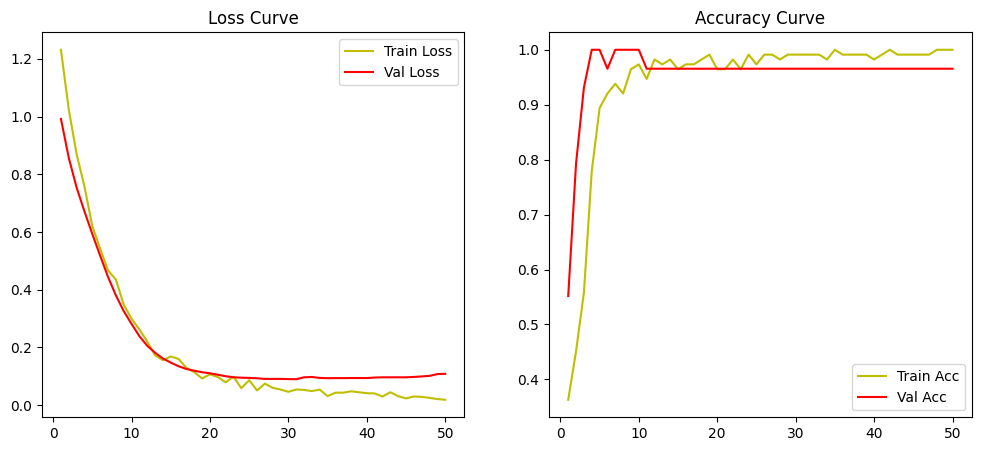


[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.86      1.00      0.92         6

    accuracy                           0.97        36
   macro avg       0.95      0.98      0.96        36
weighted avg       0.98      0.97      0.97        36


[Confusion Matrix]


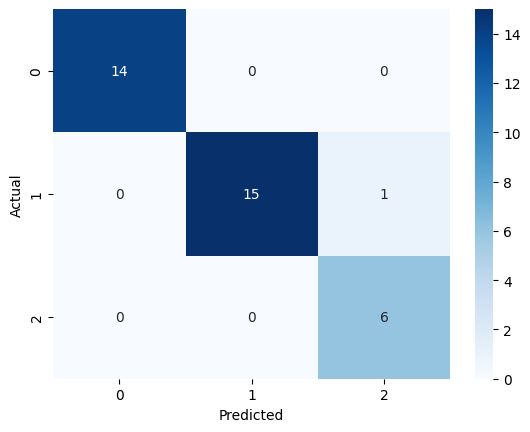

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, Input

# 1. 데이터 로드 및 전처리
data = datasets.load_wine()
data


# X, y 분리 (와인 클래스 1,2,3을 0,1,2로 변경하여 인덱스 최적화)
X = data['data']
y = data['target']

# 2. 데이터 분할 (8:2 비율)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. 데이터 스케일링 (학습 데이터 기준으로 테스트 데이터 변환)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 4. 모델 구축 (최신 Keras 권장 방식 적용)
model = models.Sequential([
    Input(shape=(X_train.shape[1],)), # 입력층 명시 (Warning 방지)
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3), # 과적합 방지
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax") # 3가지 와인 품종 분류
])

model.compile(
    optimizer="adam",
    # 정답이 숫자(0,1,2) 형태이므로 'sparse_'를 붙여줍니다!
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 5. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# 6. 예측 및 결과 분석
y_pred = model.predict(X_test)
y_pred_class = np.argmax(y_pred, axis=1) # 확률이 가장 높은 클래스 선택

# 7. 시각화 (Loss & Accuracy)
epochs_range = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], 'y', label='Train Loss')
plt.plot(epochs_range, history.history['val_loss'], 'r', label='Val Loss')
plt.title('Loss Curve'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['accuracy'], 'y', label='Train Acc')
plt.plot(epochs_range, history.history['val_accuracy'], 'r', label='Val Acc')
plt.title('Accuracy Curve'); plt.legend()
plt.show()

# 8. 최종 리포트
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_class))

print("\n[Confusion Matrix]")
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()